In [1]:
materialDensity = 1;
plateLength = 15;
plateWidth = 15;
plateThickness = 1/900000;
plateMass = materialDensity plateLength plateWidth plateThickness;
linkLength = 1;
linkThickness = 1/12 linkLength;
linkMass = materialDensity linkLength linkThickness^2;
linkRotationalInertia = 1/12 linkMass (linkLength^2 + linkThickness^2); 
wheelRadius = 1/8 linkLength;
wheelThickness = 2/3 linkThickness;
wheelMass = materialDensity π wheelRadius^2 wheelThickness; 
wheelRollingRotationalInertia = 1/2 wheelMass wheelRadius^2;
wheelPivotingRotationalInertia = 1/4 wheelMass wheelRadius^2; 
hingeRadius = 5/6 linkThickness;
hingeHeight = 3/2 linkThickness;

In [17]:
params = {M -> plateMass, m -> linkMass + wheelMass, 
   J -> linkRotationalInertia + wheelPivotingRotationalInertia, 
   R -> wheelRadius , 
   Jw -> wheelRollingRotationalInertia, Λ -> linkLength , k -> 1/1100} ;

2        2            2        2
1   Jw (x'[t]  + y'[t] )   M (X'[t]  + Y'[t] )
- + -------------------- + ------------------- + 
2              2                    2
            2 R
 
                      2                  2           2                    2
    m ((x'[t] + X'[t])  + (y'[t] + Y'[t]) )   J θ'[t]    J (α'[t] + θ'[t])
>   --------------------------------------- + -------- + ------------------ + 
                       2                         2               2
 
                         Λ Cos[θ[t]] θ'[t]   Λ Cos[α[t] + θ[t]] (α'[t] + θ'[t]) 2
>   (m ((y'[t] + Y'[t] + ----------------- + ----------------------------------)  + 
                                 2                           2
 
                          Λ Sin[θ[t]] θ'[t]   Λ Sin[α[t] + θ[t]] (α'[t] + θ'[t]) 2
>        (x'[t] + X'[t] - ----------------- - ----------------------------------) )) / 2
                                  2                           2
          2            2        2            2        2
1   k α[t]    Jw (x'[t]  + y'[t] )   M (X'[t]  + Y'[t] )
- - ------- + -------------------- + ------------------- + 
2      2                 2                    2
                      2 R
 
                      2                  2           2                    2
    m ((x'[t] + X'[t])  + (y'[t] + Y'[t]) )   J θ'[t]    J (α'[t] + θ'[t])
>   --------------------------------------- + -------- + ------------------ + 
                       2                         2               2
 
                         Λ Cos[θ[t]] θ'[t]   Λ Cos[α[t] + θ[t]] (α'[t] + θ'[t]) 2
>   (m ((y'[t] + Y'[t] + ----------------- + ----------------------------------)  + 
                                 2                           2
 
                          Λ Sin[θ[t]] θ'[t]   Λ Sin[α[t] + θ[t]] (α'[t] + θ'[t]) 2
>        (x'[t] + X'[t] - ----------------- - ----------------------------------) )) / 2
                                  2                           2
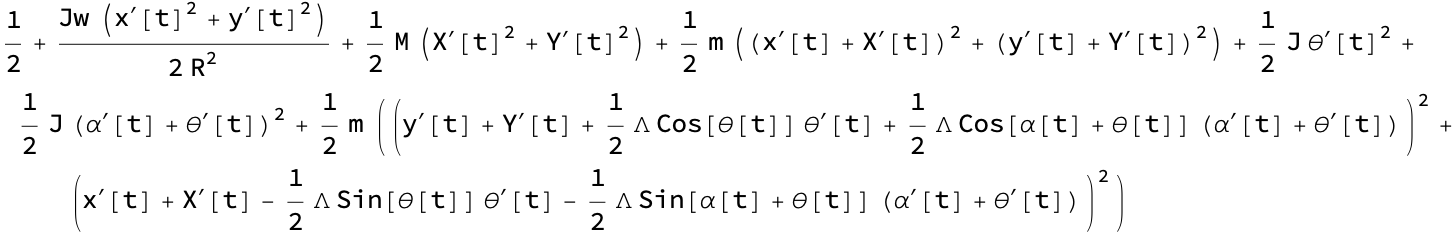
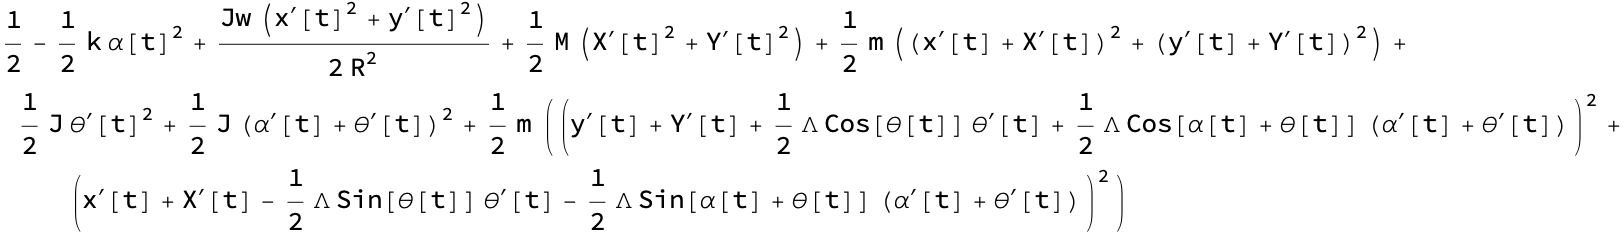

In [26]:
platePosition = {X[t], Y[t]};
firstLinkPosition = {X[t] + x[t], Y[t] + y[t]};
secondLinkPosition = 
firstLinkPosition + {Λ/2 Cos[θ[t]], Λ/2 Sin[θ[t]]} + {Λ/2 Cos[θ[t] + α[t]], Λ/2 Sin[θ[t] + α[t]]};
plateVelocity = D[platePosition, t];
firstLinkVelocity = D[firstLinkPosition, t];
secondLinkVelocity = D[secondLinkPosition, t];
firstLinkConstraint = (firstLinkVelocity - plateVelocity) . {- Sin[θ[t]], Cos[θ[t]]} == 0;
secondLinkConstraint = (secondLinkVelocity - plateVelocity) . {- Sin[θ[t] + α[t]], Cos[θ[t] + α[t]]} == 0;
KE = 1/2 M plateVelocity . plateVelocity + 1/2 m firstLinkVelocity . firstLinkVelocity  + 
   1/2 m secondLinkVelocity . secondLinkVelocity + 
   1/2 J θ'[t]^2 + 1/2 J (θ'[t] + α'[t])^2 + 1/2 Jw/R^2 (firstLinkVelocity - 
       plateVelocity) . (firstLinkVelocity - plateVelocity) + (1/2)
      Jw/R^2 (secondLinkVelocity - plateVelocity) . (secondLinkVelocity - plateVelocity);
PE = 1/2 k α[t]^2;
L = KE - PE

In [30]:
XODE = D[D[L, X'[t]], t] - D[L, X[t]] == 0;
YODE = D[D[L, Y'[t]], t] - D[L, Y[t]] == 0;
xODE = D[D[L, x'[t]], t] - D[L, x[t]] == - λ1[t] Sin[θ[t]] - λ2[t] Sin[θ[t] + α[t]];  
yODE = D[D[L, y'[t]], t] - D[L, y[t]] == λ1[t] Cos[θ[t]] + λ2[t] Cos[θ[t] + α[t]];  
θODE = D[D[L, θ'[t]], t] - D[L, θ[t]] == λ2[t] (Λ/2 + Λ/2 Cos[α[t]]);  
αODE = D[D[L, α'[t]], t] - D[L, α[t]] == λ2[t] Λ/2;     

NDSolve::pdord: Some of the functions have zero differential order, so the equations will be solved as a system of differential-algebraic equations.

{{X[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    Y[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    x[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    y[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    θ[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    α[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    X'[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    Y'[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    x'[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    y'[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    θ'[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    α'[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    λ1[t] -> InterpolatingFunction[{{0., 40.}}, <>][t], 
 
>    λ2[t] -> InterpolatingFunction[{{0., 40.}}, <>][t]}}
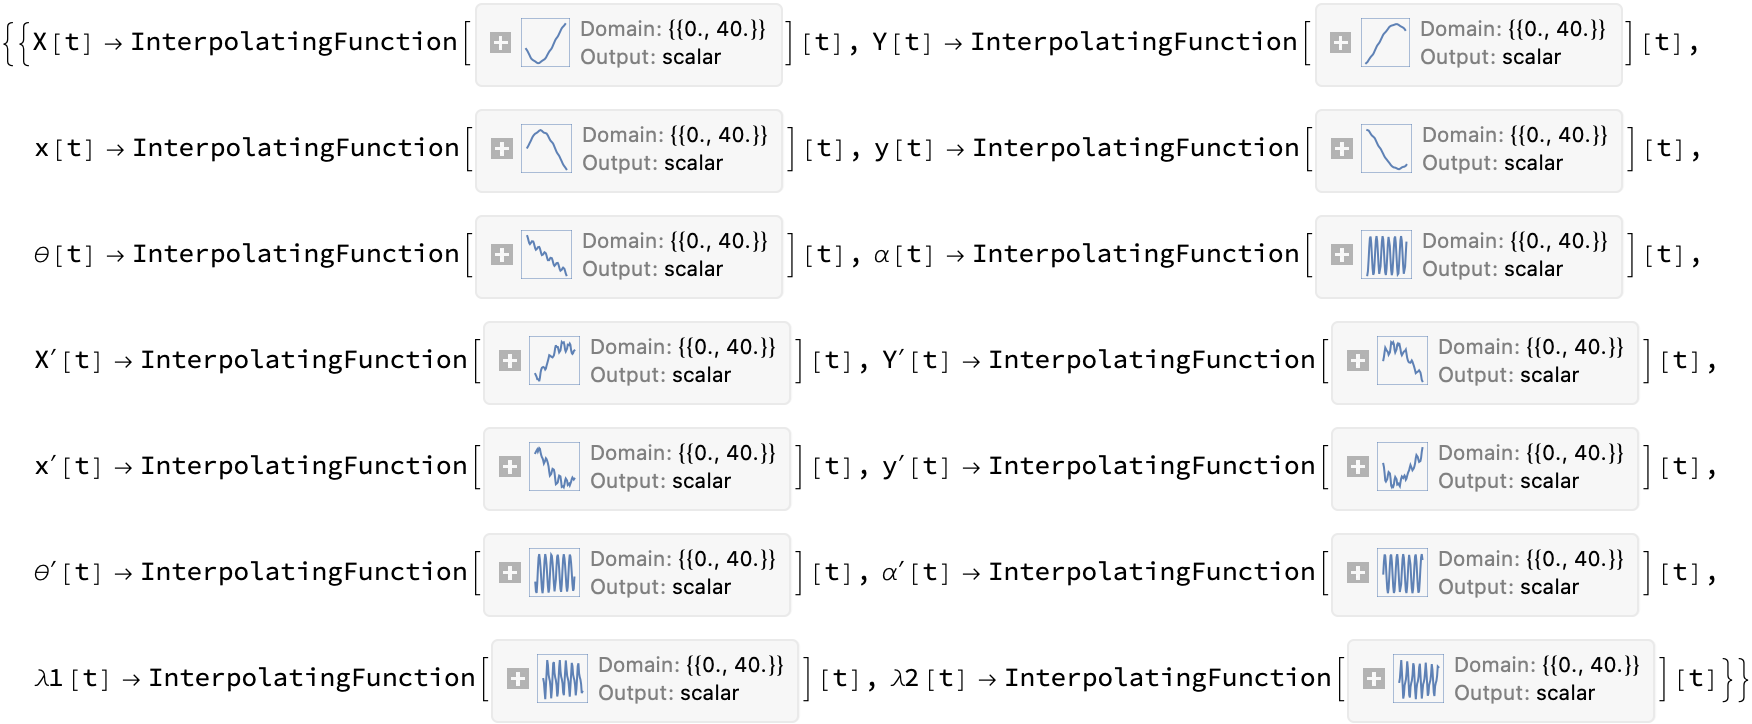

In [38]:
tInitial = 0;
tFinal = 40;
solution1 = NDSolve[{X[0] == 0, Y[0] == 0, x[0] == 0, y[0] == 0, θ[0] == 0, 
     X'[0] == - m/(M + 2 m) (1 + 1/Sqrt[2]) .3, Y'[0] ==  m/(2 m + M) 1/Sqrt[2] .3 , x'[0] == .3, 
      y'[0] == 0, θ'[0] == - 2/((1 + Sqrt[2]) linkLength) .3, α[
       0] == -(π/4),α'[0] == 0}~Join~{XODE, YODE, xODE, yODE, θODE, 
        D[firstLinkConstraint, t], D[secondLinkConstraint, t], α''[t] == 1/2 Cos[t]} /. 
         params, {X[t], Y[t], x[t], y[t], θ[t], α[t], X'[t], Y'[t], x'[t], 
            y'[t], \[Theta]'[t], α'[t], λ1[t], λ2[
             t]}, {t, tInitial, tFinal}, Method -> {"IndexReduction" -> Automatic}] 


-Graphics-
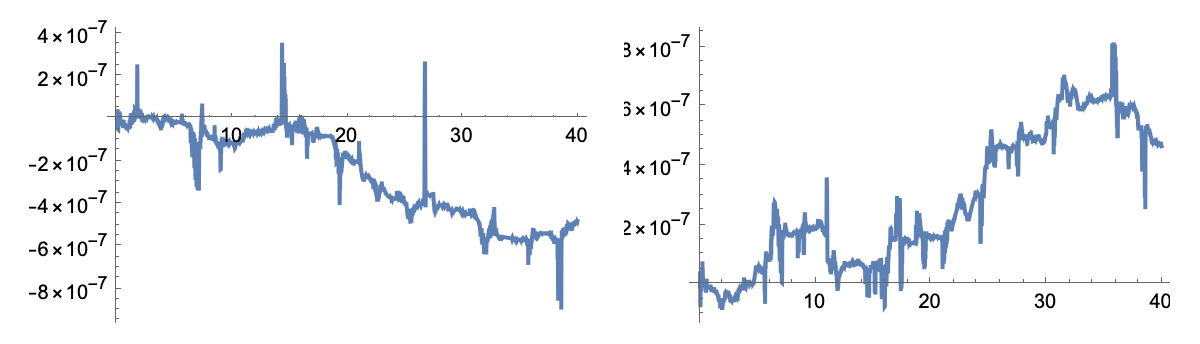

In [39]:
constraintCheck = 
 Plot[First[#] /. params /. solution1, {t, tInitial, 
      tFinal}] & /@ {firstLinkConstraint, secondLinkConstraint} // 
  GraphicsRow

-Graphics-
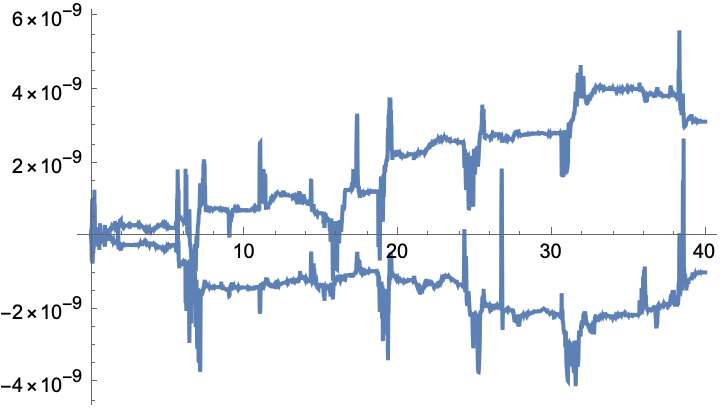

In [40]:
momentumCheck = 
 Plot[M plateVelocity + m firstLinkVelocity + m secondLinkVelocity /. 
    params /. solution1, {t, tInitial, tFinal}]

-Graphics-
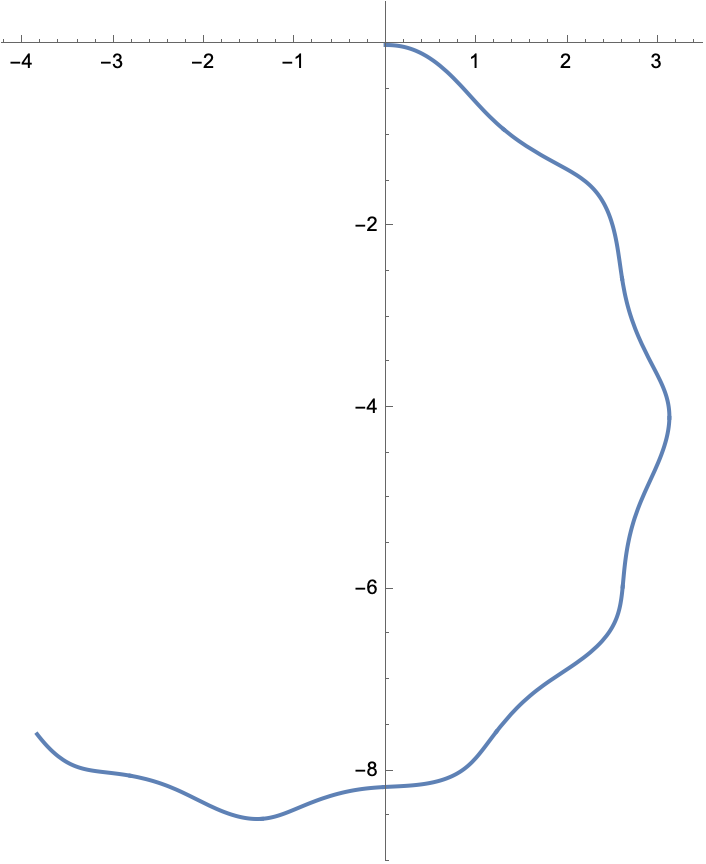

In [41]:
ParametricPlot[{x[t], y[t]} /. solution1, {t, tInitial, tFinal}]